([], [])

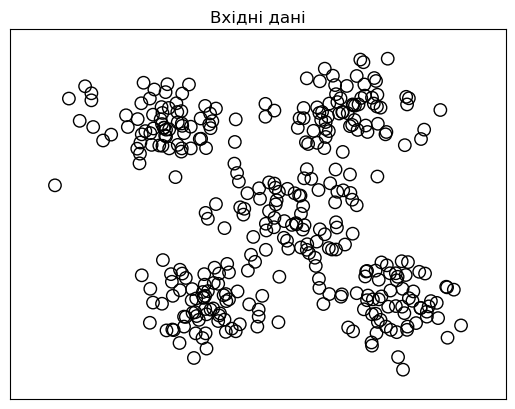

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import metrics

#завантаження даних
X = np.loadtxt('data_clustering.txt', delimiter=',')

num_clusters = 5

plt.figure()
plt.scatter(X[:,0], X[:,1], marker='o', facecolors='none',
    edgecolors='black', s=80)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
plt.title('Вхідні дані')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


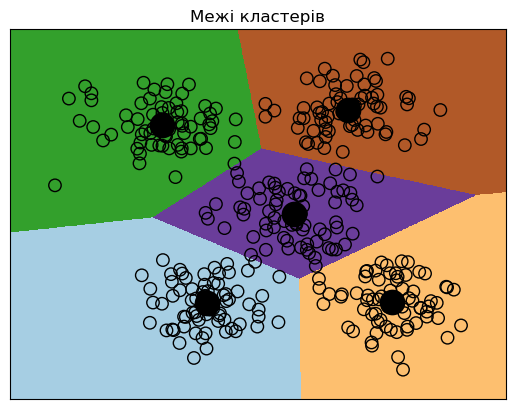

In [12]:
kmeans = KMeans(init='k-means++', n_clusters=num_clusters, n_init=10)

kmeans.fit(X)

step_size = 0.01

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

x_vals, y_vals = np.meshgrid(
    np.arange(x_min, x_max, step_size),
    np.arange(y_min, y_max, step_size)
)

output = kmeans.predict(
    np.c_[x_vals.ravel(), y_vals.ravel()]
)

#нрафічне відображення областей та виділення їх кольором
output = output.reshape(x_vals.shape)

plt.figure()
plt.clf()

plt.imshow(
    output,
    interpolation='nearest',
    extent=(
        x_vals.min(),
        x_vals.max(),
        y_vals.min(),
        y_vals.max()
    ),
    cmap=plt.cm.Paired,
    aspect='auto',
    origin='lower'
)

#відображення вхідних точок
plt.scatter(
    X[:, 0],
    X[:, 1],
    marker='o',
    facecolors='none',
    edgecolors='black',
    s=80
)

#відображення центрів кластерів
cluster_centers = kmeans.cluster_centers_

plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    marker='o',
    s=210,
    linewidths=4,
    color='black',
    zorder=12,
    facecolors='black'
)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

plt.title('Межі кластерів')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xticks(())
plt.yticks(())

plt.show()

Розмір датасету: (150, 4)
Класи: ['setosa' 'versicolor' 'virginica']


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Центри кластерів:
  Кластер 1: [5.9  2.75 4.39 1.43]
    Точок: 62
  Кластер 2: [5.01 3.43 1.46 0.25]
    Точок: 50
  Кластер 3: [6.85 3.07 5.74 2.07]
    Точок: 38


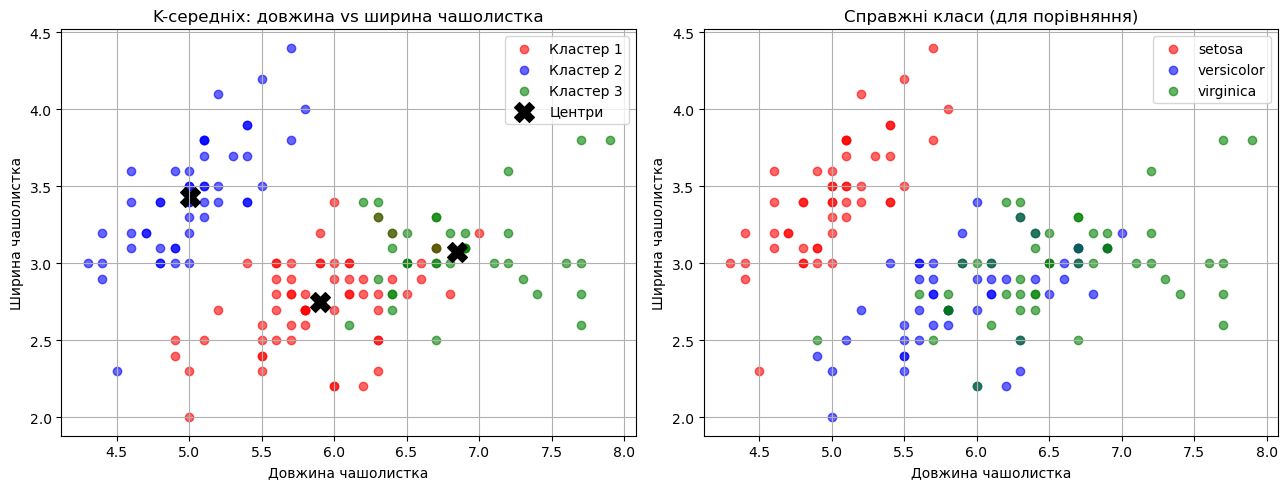


Графік збережено: iris_kmeans.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Завантаження датасету
iris = load_iris()
X = iris.data
y = iris.target  # справжні мітки (для порівняння)

print("Розмір датасету:", X.shape)
print("Класи:", iris.target_names)

# Кластеризація k-середніх (k=3, бо 3 види ірису)
model = KMeans(n_clusters=3, random_state=42)
labels = model.fit_predict(X)
centers = model.cluster_centers_

print("\nЦентри кластерів:")
for i in range(3):
    print(f"  Кластер {i+1}: {centers[i].round(2)}")
    print(f"    Точок: {(labels == i).sum()}")

# Графік 1: кластери по перших двох ознаках
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['red', 'blue', 'green']

for i in range(3):
    pts = X[labels == i]
    axes[0].scatter(pts[:, 0], pts[:, 1], color=colors[i],
                    label=f'Кластер {i+1}', alpha=0.6)
axes[0].scatter(centers[:, 0], centers[:, 1],
                color='black', marker='X', s=200, label='Центри')
axes[0].set_title('K-середніх: довжина vs ширина чашолистка')
axes[0].set_xlabel('Довжина чашолистка')
axes[0].set_ylabel('Ширина чашолистка')
axes[0].legend()
axes[0].grid(True)

# Графік 2: справжні класи для порівняння
for i in range(3):
    pts = X[y == i]
    axes[1].scatter(pts[:, 0], pts[:, 1], color=colors[i],
                    label=iris.target_names[i], alpha=0.6)
axes[1].set_title('Справжні класи (для порівняння)')
axes[1].set_xlabel('Довжина чашолистка')
axes[1].set_ylabel('Ширина чашолистка')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('iris_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nГрафік збережено: iris_kmeans.png")

In [24]:
import datetime
import json
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn import covariance, cluster

# 1. Завантаження мапінгу компаній безпосередньо з URL
url = "https://raw.githubusercontent.com/PacktPublishing/Artificial-Intelligence-with-Python/refs/heads/master/Chapter%2004/code/company_symbol_mapping.json"
company_symbols_map = pd.read_json(url, typ='series').to_dict()

symbols = list(company_symbols_map.keys())
names = np.array(list(company_symbols_map.values()))

# 2. Визначення часових меж (як у вашому завданні)
start_date = "2003-07-03"
end_date = "2007-05-04"

print("Завантаження даних з Yahoo Finance... зачекайте.")

# 3. Отримання даних одним запитом (це швидше і надійніше)
data = yf.download(symbols, start=start_date, end=end_date)

# Вибираємо ціни відкриття та закриття
# Видаляємо акції, за якими немає повних даних (якщо такі є)
data = data.dropna(axis=1)
opening_quotes = data['Open'].values  # Матриця: дні x компанії
closing_quotes = data['Close'].values

# Оновлюємо список назв компаній, щоб він відповідав завантаженим даним
valid_symbols = data['Open'].columns
names = np.array([company_symbols_map[s] for s in valid_symbols])

# 4. Обчислення різниці та нормалізація
# Різниця між закриттям і відкриттям (зміна ціни за день)
quotes_diff = closing_quotes - opening_quotes

# Транспонуємо, щоб рядками були компанії (для кластеризації компаній)
X = quotes_diff.T 
X /= X.std(axis=1)[:, np.newaxis] # Нормалізуємо по компаніях

# 5. Створення та навчання моделі графа (GraphicalLassoCV)
# Використовуємо сучасну назву GraphicalLassoCV
edge_model = covariance.GraphicalLassoCV()

print("Навчання моделі графа...")
with np.errstate(invalid='ignore'):
    edge_model.fit(X.T) # Навчаємо на транспонованих даних (дні як спостереження)

# 6. Кластеризація (Affinity Propagation)
# Використовуємо матрицю коваріації як міру подібності
_, labels = cluster.affinity_propagation(edge_model.covariance_, random_state=0)
num_labels = labels.max()

print("\nРЕЗУЛЬТАТИ КЛАСТЕРИЗАЦІЇ:\n" + "="*30)
for i in range(num_labels + 1):
    cluster_names = names[labels == i]
    if len(cluster_names) > 0:
        print(f"Cluster {i+1} ==> {', '.join(cluster_names)}")

ModuleNotFoundError: No module named 'yfinance'

In [26]:
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth

#завантаження даних
data = np.loadtxt("data_clustering.txt", delimiter=",")

#оцінка bandwidth
bandwidth = estimate_bandwidth(data, quantile=0.2)

#модель Mean Shift
model = MeanShift(bandwidth=bandwidth)
model.fit(data)

#кількість кластерів
labels = model.labels_
clusters = len(np.unique(labels))

print("Кількість кластерів:", clusters)

Кількість кластерів: 5


In [31]:
import numpy as np
import requests
from sklearn.cluster import AffinityPropagation

np.random.seed(42)

n = 50
open_prices = np.random.uniform(50, 150, n)
close_prices = open_prices + np.random.normal(0, 5, n)

X = (close_prices - open_prices).reshape(-1, 1)

model = AffinityPropagation(random_state=0)
model.fit(X)

labels = model.labels_
clusters = len(np.unique(labels))

print("Кількість підгруп:", clusters)

url = "https://raw.githubusercontent.com/PacktPublishing/Artificial-Intelligence-with-Python/refs/heads/master/Chapter%2004/code/company_symbol_mapping.json"

mapping = requests.get(url).json()

Кількість підгруп: 6
